# Week 5 Exercise: Building Sinusoids, Practicing Python, Understanding Digital Audio
Complete this activity as part of your participation grade. 

All of the answers can be found in Lessons 01-05 jupyter notebooks. Try your best to complete this assignment on your own. It is in your best interest to work through these Python examples, so that you can better follow along in lecture.

## Environment Set-up

<b>Before starting this exercise, you must follow Lesson01a to set-up Python, GitHub, and VS Code on your computer. 

If you complete nothing else from exercise, please do this!!!</b>

## Loading, playing, and plotting an audio file. 

1) Read in a .wav file (from the Audio folder) and assign it a variable name. (You will need to import a Python library)

In [144]:
from scipy.io.wavfile import read
(fs, x) = read("../../AudioTechI/audio/flute-A4.wav")

2) Playback your audio file

In [145]:
from IPython.display import Audio
Audio(x, rate=fs)

3) Figure out the length of the .wav file in samples and its duration in seconds. If your file is longer than 5 seconds, truncate the file so it is less than 5 seconds in length.

In [146]:
size = x.size
length = size/fs
if length > 5:
    x = x[0:5*fs]

4) Make a plot of your file (or segment of your file). **Make sure the x-axis shows time in seconds**, label your axes, and provide a title.

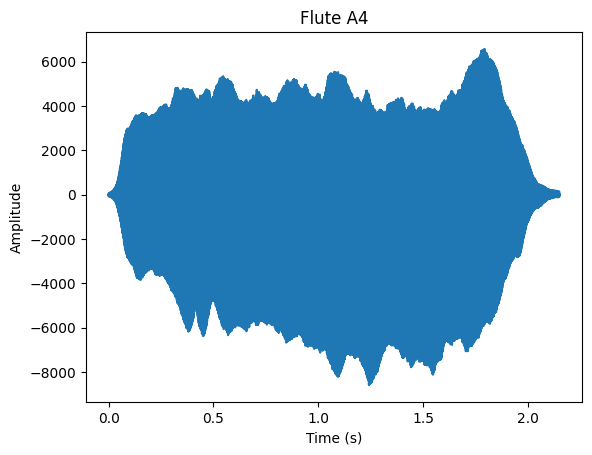

In [147]:
from matplotlib import pyplot as plt
import numpy as np
t = np.arange(x.size)/fs
plt.plot(t, x)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Flute A4')
plt.show()

## Sinusoids

1) Create (and then plot) a sinusoid of 44Hz, with amplitude of 2, and a sample rate of 22,050 that lasts 2 seconds.

Text(0.5, 1.0, 'Sine Wave: 44 Hz, 2 Amplitude')

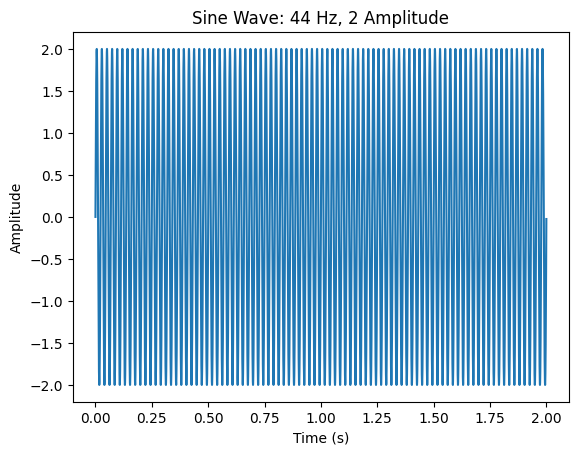

In [148]:
freq = 44
amp = 2
fs = 22050
time = 2
t = np.arange(0, time, 1/fs)
x = amp * np.sin(2 * np.pi * freq * t)
plt.plot(t, x)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Sine Wave: 44 Hz, 2 Amplitude')

2) Play back your sinusoid (SET VOLUME FIRST!)

In [149]:
bits = 2
levels = 2**bits
steps = 2 / levels

x_quant = np.round(x / steps) * steps
Audio(x_quant, rate=fs)

3) Change the plot (don't just zoom in) such that you see only the first 10 cycles. Change the x-axis of your plot to show milliseconds.

Text(0.5, 1.0, 'Quantized Signal: 44 Hz, 2 Amplitude, 1st 10 Cycles')

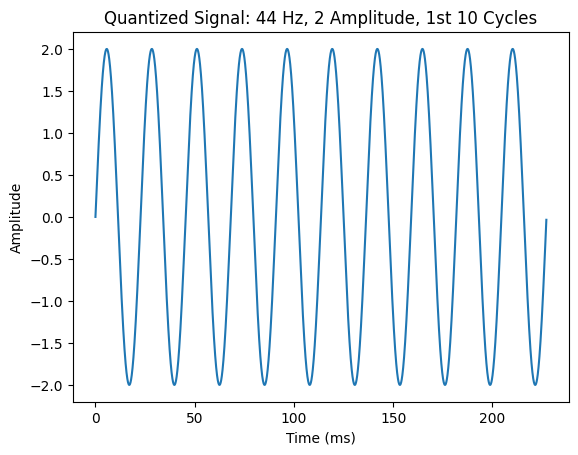

In [150]:
num_samples = int(10/44 * fs)
t_10 = t[:num_samples] * 1000
x_10 = x[:num_samples]
plt.plot(t_10, x_10)
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.title('Quantized Signal: 44 Hz, 2 Amplitude, 1st 10 Cycles')

4) Write a function called genSine() which returns a sinusoid given frequency, phase offset, amplitude, sampling rate, and duration in seconds(remember you can use default parameters where appropriate)

In [151]:
def genSine(freq, phase=0, amp=1, fs=44100, time=1):
    t = np.arange(0, time, 1/fs)
    sine = amp * np.sin(2 * np.pi * freq * t + phase)
    return sine

5. Plot 2 harmonic sinusoids with different amplitudes on top of each other using your function to generate the signals.

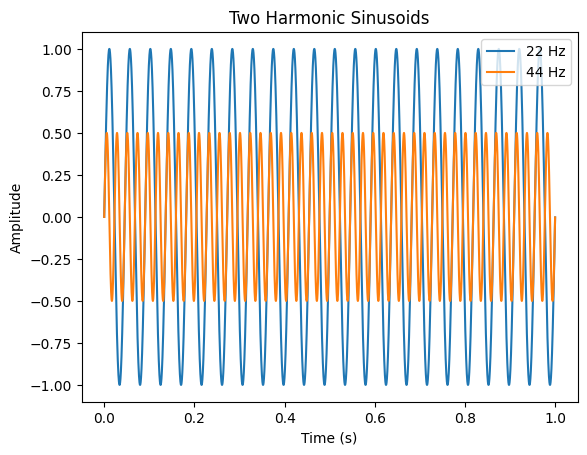

In [152]:
sine1 = genSine(22)
sine2 = genSine(44, 0, 0.5)
t = np.arange(0, 1, 1/44100)
plt.plot(t, sine1, label="22 Hz")
plt.plot(t, sine2, label="44 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Two Harmonic Sinusoids")
plt.legend()
plt.show()

## Extra Practice: Digital Audio - Sampling

1) Using your genSine function, create a sinusoid within a comfortable range in Hz of human hearing. It should cover 2s of duration and have a reasonable sampling rate. Play it back (with LOW volume!!)

2) What is the lowest sampling rate you can convert the sinusoid to and still hear the sound as a sinusoid at the appropriate pitch height? (Note: the `Audio` widget will not playback anything with a rate less than 3000 in Chrome and some other browsers - this can affect your mileage with this question!!)

3) Create a sinusoidal signal, $s$ with a fixed sampling rate of 10kHz.  Try to play back your sinusoid under differing conditions:

* change the frequency in Hz
* change the playback speed by altering the "rate" parameter in Audio

In doing this, try to examine for yourself the relation between the Nyquist frequency and aliasing. Make plots if it helps.

4) Create two scenarios where you obtain an aliased frequency of approximately 200Hz (that you can (hypothetically) hear).

5) Write a function to calculate aliased frequencies. Note: if sample rate is an even number, subtract 1 from sample rate first.